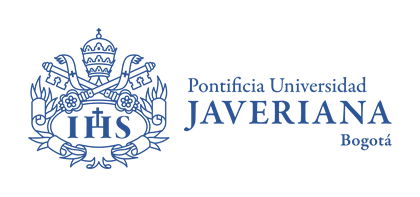

# Aprendizaje de máquina - Laboratorio Naive Bayes
El modelo naive bayes de clasificación permite formular clasificadores maximizando la verosimilitud del modelo sobre los parámetros. Dependiendo del modelo e información disponible, cada modelo utiliza sus parámetros de forma diferente. Lo interesante de estos tipos de modelos vistos en clase es que al maximizar la probabilidad de los mismos, los parámetros resultan siendo elementos simples y fáciles de calcular para los modelos gaussianos y naive bayes.

Los objetivos de este notebook son los siguientes:

*   Revisar el comportamiento de los modelos gaussianos y multinomal bernoulli usando sklearn en python
*   Comparar modelo multinomial con regresión logística


**Créditos**

Este notebook esta adaptado a partir del contenido del libro  Python Data Science Handbook de Jake VanderPlas disponible en Github [on GitHub](https://github.com/jakevdp/PythonDataScienceHandbook).

* El libro esta liberado bajo licencia creative commons [CC-BY-NC-ND license](https://creativecommons.org/licenses/by-nc-nd/3.0/us/legalcode)

# Import de librerias

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.naive_bayes import GaussianNB
from sklearn.datasets import make_blobs
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline
from sklearn.metrics import confusion_matrix
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score


## Modelo gaussiano

El modelo generativo gaussiano asume que la probabilidad que una instancia pertenezca a una clase $y$ esta dado por una probabilidad de una distribución gausiana con promedio $\mu\in \mathbb{R}^m$ y covarianza $\Sigma$

$P(x|y)=\frac{1}{2\pi^{n/2} |\Sigma|^{1/2}}exp(-\frac{1}{2}(x-\mu_{y})^{T}\Sigma^{-1}(x-\mu_{y}))$

Consideremos los siguientes puntos sintéticos, usando 2 clases que están agrupadas frente a su promedio

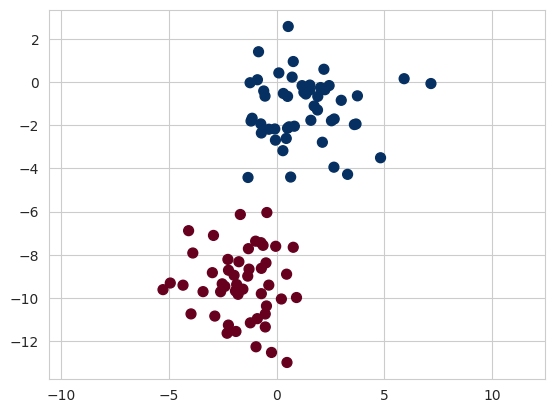

In [2]:
sns.set_style("whitegrid")
X, y = make_blobs(100, 2, centers=2, random_state=2, cluster_std=1.5)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='RdBu');
plt.axis('equal');

Usando el modelo naive bayes, vamos a entrenar un modelo gaussiano para encontrar los parámetros $\mu$ por clase y $\Sigma$

In [3]:
model = GaussianNB()
model.fit(X, y)

GaussianNB()

In [4]:
# Probabilidad por clase, son equiprobables por que los conteos son iguales
model.class_prior_

array([0.5, 0.5])

In [5]:
# Promedios por clase, clase 0 es la roja y clase 1 la azul (theta = miu [Centroides de las clases])
model.theta_

array([[-1.64939095, -9.36891451],
       [ 1.29327924, -1.24101221]])

In [6]:
# Varianza de los datos (varianza por clase y por feature), supone independencia
model.var_

array([[2.06097005, 2.47716872],
       [3.33164807, 2.22401384]])

Ilustremos la distribución de probabilidad aprendida sobre una grilla

In [29]:
padding = 1.0
x_min, x_max = X[:,0].min() - padding, X[:,0].max() + padding
y_min, y_max = X[:,1].min() - padding, X[:,1].max() + padding
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)
grid = np.c_[xx.ravel(), yy.ravel()]
print(grid)

[[ -6.26927614 -13.99688015]
 [ -6.22103011 -13.99688015]
 [ -6.17278407 -13.99688015]
 ...
 [  8.05979642   3.58439015]
 [  8.10804246   3.58439015]
 [  8.15628849   3.58439015]]


In [8]:



# Definición función de probabilidad para X, usa covarianza diagonal (gaussiana)
def gaussian_likelihood(X, mean, var):
    d = X.shape[1]
    norm_const = (2*np.pi)**(-d/2) * np.prod(var**-0.5)
    diff = X - mean
    expo = -0.5 * np.sum((diff**2) / var, axis=1)
    return norm_const * np.exp(expo)

In [9]:

eps = 1e-6
# Corremos el modelo para obtener la distribución de la grilla por cada clase
likelihoods = []
for k, cls in enumerate(model.classes_):
    mu_k = model.theta_[k]
    var_k = model.var_[k]
    lk = gaussian_likelihood(grid, mu_k, var_k).reshape(xx.shape)
    likelihoods.append(lk)

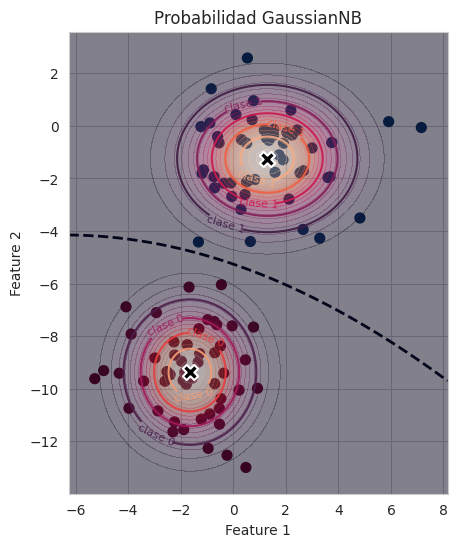

In [10]:

fig, ax = plt.subplots(figsize=(7,6))

# Diagrama dispersion original
ax.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='RdBu')
ax.set_aspect('equal', adjustable='box')

levels = 6  # niveles de countour
for k, lk in enumerate(likelihoods):
    cs = ax.contour(xx, yy, lk, levels=levels, alpha=0.9)
    cf = ax.contourf(xx, yy, lk, levels=20, alpha=0.3)
    ax.clabel(cs, inline=True, fontsize=8, fmt={lev: f"clase {model.classes_[k]}" for lev in cs.levels})

# Probabilidad posterior de la última clase (model.classes_[-1])
proba = model.predict_proba(grid)[:, -1].reshape(xx.shape)

# Curva de nivel 0.5 (frontera de decisión)
cs_boundary = ax.contour(xx, yy, proba, levels=[0.5],
                         linewidths=2.0, linestyles='--')


ax.scatter(
    model.theta_[:, 0],
    model.theta_[:, 1],
    c="black",
    s=120,
    marker="X",
    edgecolor="white",
    linewidth=1.5,
    label="Promedios"
)

ax.set_title("Probabilidad GaussianNB")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")

plt.show()

Prueba de como le iría a una logistica

In [11]:
logreg = LogisticRegression()
logreg.fit(X, y)

LogisticRegression()

In [12]:
proba_lr = logreg.predict_proba(grid)[:, 1].reshape(xx.shape)

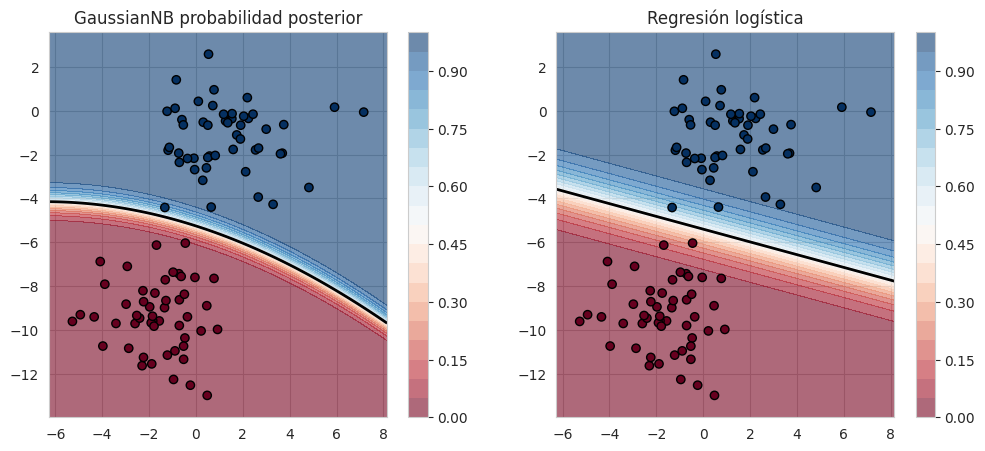

In [13]:

proba_nb = model.predict_proba(grid)[:, 1].reshape(xx.shape)
proba_lr = logreg.predict_proba(grid)[:, 1].reshape(xx.shape)


fig, axs = plt.subplots(1, 2, figsize=(12,5))

# GaussianNB
cf1 = axs[0].contourf(xx, yy, proba_nb, levels=20, cmap='RdBu', alpha=0.6)
axs[0].scatter(X[:, 0], X[:, 1], c=y, cmap='RdBu', edgecolor="k")
axs[0].contour(xx, yy, proba_nb, levels=[0.5], colors="black", linewidths=2)
axs[0].set_title("GaussianNB probabilidad posterior")
fig.colorbar(cf1, ax=axs[0])

# Logistic Regression
cf2 = axs[1].contourf(xx, yy, proba_lr, levels=20, cmap='RdBu', alpha=0.6)
axs[1].scatter(X[:, 0], X[:, 1], c=y, cmap='RdBu', edgecolor="k")
axs[1].contour(xx, yy, proba_lr, levels=[0.5], colors="black", linewidths=2)
axs[1].set_title("Regresión logística")
fig.colorbar(cf2, ax=axs[1])

plt.show()

# Naive bayes multinomial

El Naive Bayes multinomialasume que las características se generan a partir de una distribución multinomial simple.

La distribución multinomial describe la probabilidad de observar conteos entre un número de categorías y, por lo tanto, el Naive Bayes multinomial es más apropiado para características que representan conteos o tasas de conteo.

La idea es exactamente la misma que antes, excepto que en lugar de modelar la distribución de los datos con la gaussiana de mejor ajuste, la modelamos con una distribución multinomial de mejor ajuste.

## Clasificación de texto

Un lugar donde se usa con frecuencia el Naive Bayes multinomial es en la clasificación de textos, donde las características están relacionadas con los conteos de palabras o las frecuencias dentro de los documentos a clasificar.


Vamos a descargar los datos y observar los nombres de las clases objetivo:

In [14]:
data = fetch_20newsgroups()
data.target_names

['alt.atheism',
 'comp.graphics',
 'comp.os.ms-windows.misc',
 'comp.sys.ibm.pc.hardware',
 'comp.sys.mac.hardware',
 'comp.windows.x',
 'misc.forsale',
 'rec.autos',
 'rec.motorcycles',
 'rec.sport.baseball',
 'rec.sport.hockey',
 'sci.crypt',
 'sci.electronics',
 'sci.med',
 'sci.space',
 'soc.religion.christian',
 'talk.politics.guns',
 'talk.politics.mideast',
 'talk.politics.misc',
 'talk.religion.misc']

Por facilidad vamos a limitar el análisis a 4 categorías



In [15]:
categories = ['talk.religion.misc', 'soc.religion.christian',
              'sci.space', 'comp.graphics']
train = fetch_20newsgroups(subset='train', categories=categories)
test = fetch_20newsgroups(subset='test', categories=categories)

In [16]:
# Ejemplo, primeros 48 caracteres de la instancia 6
print(train.data[5][48:])

Subject: Federal Hearing
Originator: dmcgee@uluhe
Organization: School of Ocean and Earth Science and Technology
Distribution: usa
Lines: 10


Fact or rumor....?  Madalyn Murray O'Hare an atheist who eliminated the
use of the bible reading and prayer in public schools 15 years ago is now
going to appear before the FCC with a petition to stop the reading of the
Gospel on the airways of America.  And she is also campaigning to remove
Christmas programs, songs, etc from the public schools.  If it is true
then mail to Federal Communications Commission 1919 H Street Washington DC
20054 expressing your opposition to her request.  Reference Petition number

2493.



Para convertir el texto en una matriz documento término usaremos [TFidfVectorizer](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html) para convertir los textos a una matriz con entradas TF-IDF. Recuerde que en el modelo Bernoulli se revisa solamente presencia, en cambio en el modelo Multinomial se tiene en cuenta los conteos o en este caso proporciones indicadas por los valores TF-IDF.

La probabilidad estimada por el modelo multinomial es $ P(w_j\mid y=k) = \frac{N_{kj}+\alpha} {\sum_r N_{kr}+\alpha V} $, donde $N_{kj}$ es la suma del conteo o peso TF‑IDF de la característica $j$ en los documentos de la clase $k$

$V$ es el tamaño del vocabulario, es decir, el número total de características o términos diferentes generados por TfidfVectorizer. En el notebook puede consultarse con:

In [17]:
model = make_pipeline(TfidfVectorizer(), MultinomialNB())

$\alpha$ es el parámetro de suavizado aditivo, parecido a laplace para evitar probabilidades o conteos en 0

Fit-predict

In [18]:
model.fit(train.data, train.target)
labels = model.predict(test.data)

In [19]:
# Logs de probabilidad (priors) de cada clase / son negativos xq son logs, al ser log solo los sumo (eso es lo mismo que multiplicar sin perder error de cálculo)
log_priors=model[1].class_log_prior_
log_priors

array([-1.30471651, -1.2894231 , -1.2793559 , -1.74237231])

In [20]:
probs = np.exp(log_priors) / np.exp(log_priors).sum()
print("Priors as probabilities:", probs)

Priors as probabilities: [0.27124942 0.27542963 0.27821644 0.17510451]


In [21]:
# Se crea un conteo por cada clase, para 35329 palabras
model[1].feature_count_.shape

(4, 35329)

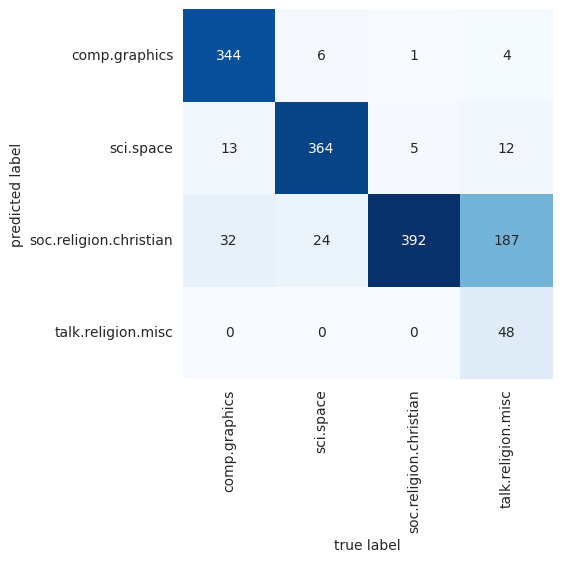

In [22]:
mat = confusion_matrix(test.target, labels)
sns.heatmap(mat.T, square=True, annot=True, fmt='d', cbar=False,
            xticklabels=train.target_names, yticklabels=train.target_names,
            cmap='Blues')
plt.xlabel('true label')
plt.ylabel('predicted label');

In [38]:
# Existen métricas de clasificación a nivel micro, macro

# Micro Calcula TP, TN, FP, FN sumando aciertos y desaciertos por clase
nb_precision = precision_score(test.target, labels, average='macro')
nb_recall = recall_score(test.target, labels, average='macro')
nb_f1 = f1_score(test.target, labels, average='macro')
nb_accuracy = accuracy_score(test.target, labels)

print(f"Accuracy: {nb_accuracy:.3f}")
print(f"Precision: {nb_precision:.3f}")
print(f"Recall:    {nb_recall:.3f}")
print(f"F1 score:  {nb_f1:.3f}")

Accuracy: 0.802
Precision: 0.802
Recall:    0.802
F1 score:  0.802


In [24]:
# Macro Calcula TP, TN, FP, FN por clase y reporta promedios
precision = precision_score(test.target, labels,average='macro')
recall = recall_score(test.target, labels,average='macro')
f1 = f1_score(test.target, labels,average='macro')

print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1 score:  {f1:.3f}")

Precision: 0.878
Recall:    0.746
F1 score:  0.732


# Ejercicio

Cree un modelo de clasificación logística sobre el ejercicio de los newsgroups, compare resultados y realice conclusiones sobre el ejercicio

In [25]:
logreg_model = make_pipeline(TfidfVectorizer(), LogisticRegression(max_iter=1000)) # Increased max_iter for convergence
logreg_model.fit(train.data, train.target)
logreg_labels = logreg_model.predict(test.data)

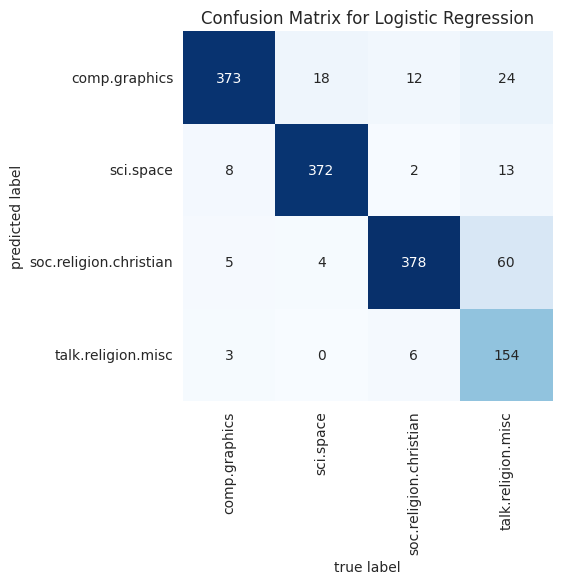

In [26]:
# Confusion Matrix
mat_logreg = confusion_matrix(test.target, logreg_labels)
sns.heatmap(mat_logreg.T, square=True, annot=True, fmt='d', cbar=False,
            xticklabels=train.target_names, yticklabels=train.target_names,
            cmap='Blues')
plt.xlabel('true label')
plt.ylabel('predicted label')
plt.title('Confusion Matrix for Logistic Regression')
plt.show()

In [27]:
# Micro-averaged metrics
precision_micro = precision_score(test.target, logreg_labels, average='micro')
recall_micro = recall_score(test.target, logreg_labels, average='micro')
f1_micro = f1_score(test.target, logreg_labels, average='micro')

print(f"\nMicro-averaged Precision: {precision_micro:.3f}")
print(f"Micro-averaged Recall:    {recall_micro:.3f}")
print(f"Micro-averaged F1 score:  {f1_micro:.3f}")


Micro-averaged Precision: 0.892
Micro-averaged Recall:    0.892
Micro-averaged F1 score:  0.892


In [41]:
# Macro-averaged metrics
lr_precision = precision_score(test.target, logreg_labels, average='macro')
lr_recall = recall_score(test.target, logreg_labels, average='macro')
lr_f1 = f1_score(test.target, logreg_labels, average='macro')
lr_accuracy = accuracy_score(test.target, logreg_labels)

print(f"Accuracy: {lr_accuracy:.3f}")
print(f"Precision: {lr_precision:.3f}")
print(f"Recall:    {lr_recall:.3f}")
print(f"F1 score:  {lr_f1:.3f}")

Accuracy: 0.892
Precision: 0.901
Recall:    0.867
F1 score:  0.874


## Comparación

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score


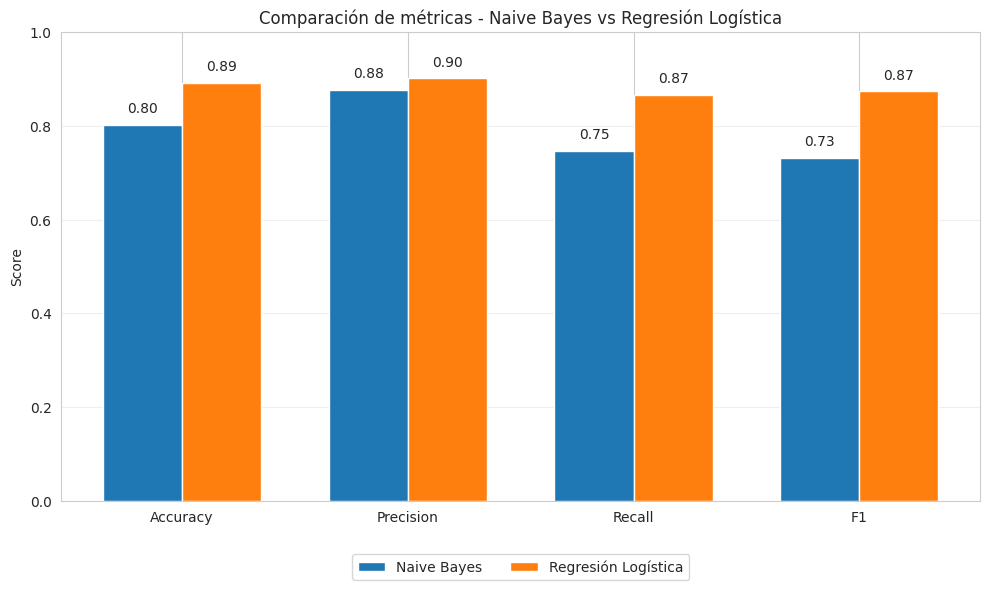

In [46]:
import numpy as np
import matplotlib.pyplot as plt

# F1 de Naive Bayes: promedio de las clases
nb_f1 = np.mean(nb_f1)

metricas = ['Accuracy', 'Precision', 'Recall', 'F1']

nb_values = [
    nb_accuracy,
    nb_precision,
    nb_recall,
    nb_f1
]

lr_values = [
    lr_accuracy,
    lr_precision,
    lr_recall,
    lr_f1
]

x = np.arange(len(metricas))
width = 0.35

plt.figure(figsize=(10, 6))

bars_nb = plt.bar(
    x - width/2,
    nb_values,
    width,
    label='Naive Bayes'
)

bars_lr = plt.bar(
    x + width/2,
    lr_values,
    width,
    label='Regresión Logística'
)

# Valores encima de cada barra
for bars in [bars_nb, bars_lr]:
    for bar in bars:
        valor = bar.get_height()

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            valor + 0.02,
            f'{valor:.2f}',
            ha='center',
            va='bottom',
            fontsize=10
        )

plt.ylabel('Score')
plt.title('Comparación de métricas - Naive Bayes vs Regresión Logística')
plt.xticks(x, metricas)
plt.ylim(0, 1)

# Leyenda ABAJO
plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.10),
    ncol=2
)

plt.grid(axis='y', alpha=0.3)

# Ajustar espacio para la leyenda
plt.tight_layout()

plt.show()


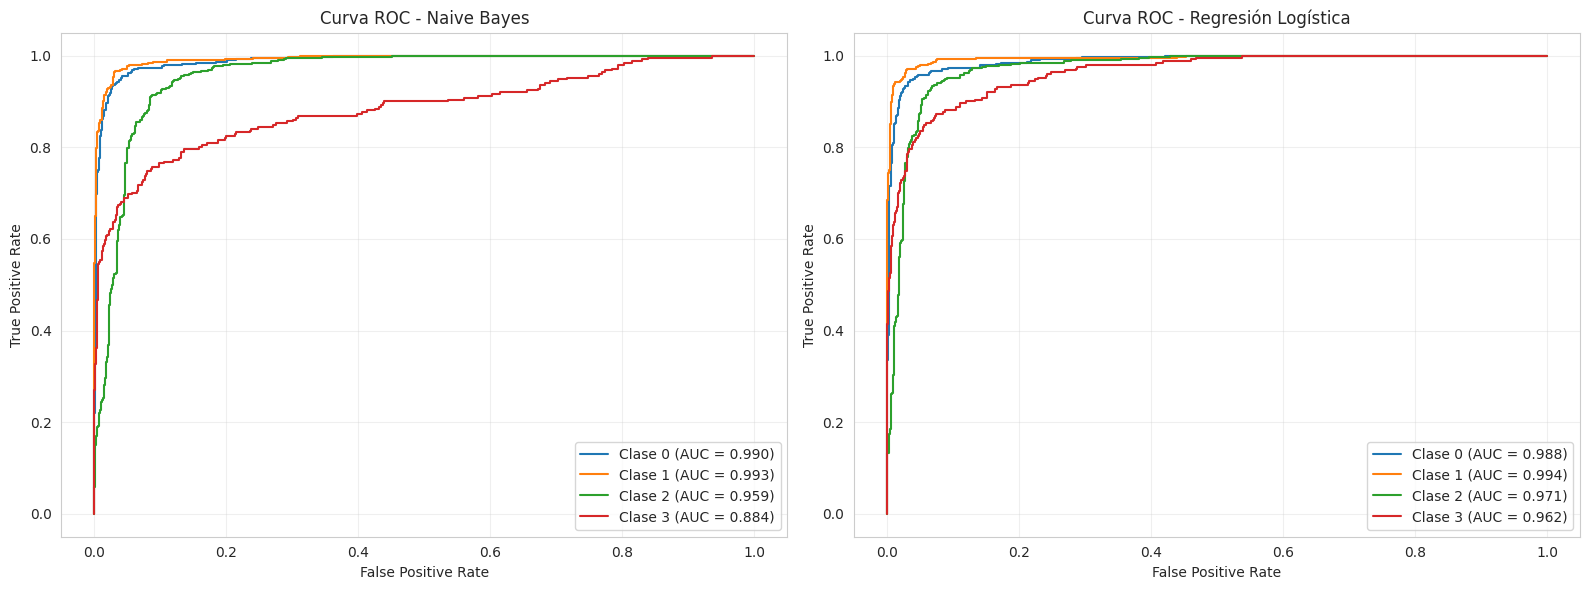

In [36]:
# Clases
classes = np.unique(test.target)
# Convertir etiquetas reales a formato binario
y_test_bin = label_binarize(test.target, classes=classes)
# Probabilidades de cada modelo
logreg_proba = logreg_model.predict_proba(test.data)
nb_proba = model.predict_proba(test.data)



# ROC - Naive Bayes
fpr_nb = {}
tpr_nb = {}
roc_auc_nb = {}

for i in range(len(classes)):
    fpr_nb[i], tpr_nb[i], _ = roc_curve(y_test_bin[:, i],nb_proba[:, i])
    roc_auc_nb[i] = auc(fpr_nb[i], tpr_nb[i])



# ROC - Regresión Logística
fpr_lr = {}
tpr_lr = {}
roc_auc_lr = {}

for i in range(len(classes)):
    fpr_lr[i], tpr_lr[i], _ = roc_curve(y_test_bin[:, i],logreg_proba[:, i])
    roc_auc_lr[i] = auc(fpr_lr[i], tpr_lr[i])




fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfica 1 - Naive Bayes
for i, class_name in enumerate(classes):
    axes[0].plot(fpr_nb[i],tpr_nb[i],label=f'Clase {class_name} (AUC = {roc_auc_nb[i]:.3f})')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('Curva ROC - Naive Bayes')
axes[0].legend(loc='lower right')
axes[0].grid(alpha=0.3)


# Gráfica 2 - Regresión Logística
for i, class_name in enumerate(classes):
    axes[1].plot(fpr_lr[i],tpr_lr[i],label=f'Clase {class_name} (AUC = {roc_auc_lr[i]:.3f})')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Curva ROC - Regresión Logística')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()
